In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 1. Import Libraries
# ==============================
import pandas as pd
import numpy as np
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt

In [3]:
# ==============================
# 2. Load Dataset
# ==============================
df = pd.read_csv(
    '/content/drive/My Drive/Colab Notebooks/Research/Diabetes/diabetes_012_health_indicators_BRFSS2015.csv'
)

print("Dataset Shape:", df.shape)

Dataset Shape: (253680, 22)


In [4]:
# ==============================
# 3. Features & Target
# ==============================
X = df.drop('Diabetes_012', axis=1)
y = df['Diabetes_012']


# ==============================
# 4. Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [5]:
# ==============================
# 5. Feature Scaling
# ==============================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Before SMOTE:")
print(pd.Series(y_train).value_counts())


# ==============================
# 6. Apply SMOTE (Only on Training Data)
# ==============================
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_train).value_counts())

Before SMOTE:
Diabetes_012
0.0    149592
2.0     24742
1.0      3242
Name: count, dtype: int64
After SMOTE:
Diabetes_012
0.0    149592
2.0    149592
1.0    149592
Name: count, dtype: int64


In [6]:
model = XGBClassifier(
    n_estimators=110,
    learning_rate=0.13,
    max_depth=11,
    random_state=42,
    eval_metric='logloss'
)

# ==============================
# 7. Train Model
# ==============================
model.fit(X_train, y_train)


# ==============================
# 8. Evaluate Model
# ==============================
accuracy = model.score(X_test, y_test)

print("\nTest Accuracy:", accuracy)


Test Accuracy: 0.8450015767896563


In [7]:
# ==============================
# 9. Predictions
# ==============================
y_pred = model.predict(X_test)

In [8]:
# ==============================
# 10. Metrics
# ==============================
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[61602     4  2505]
 [ 1170     0   219]
 [ 7897     1  2706]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.96      0.91     64111
         1.0       0.00      0.00      0.00      1389
         2.0       0.50      0.26      0.34     10604

    accuracy                           0.85     76104
   macro avg       0.46      0.41      0.42     76104
weighted avg       0.80      0.85      0.82     76104



In [9]:
# Manual Metrics
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("\nPrecision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Precision: 0.8037663097161161
Recall: 0.8450015767896563
F1 Score: 0.8170900916065342


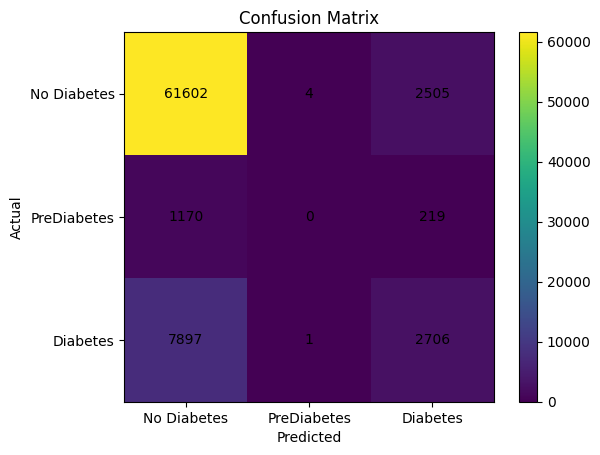

In [10]:
# ==============================
# 11. Confusion Matrix Visualization
# ==============================
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

# Labels
classes = ['No Diabetes', 'PreDiabetes', 'Diabetes']
tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

# Annotate values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()